In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [10]:
dataset = pd.read_csv("Housing.csv")

In [14]:
# dataset.head()

In [13]:
dataset.drop(columns=["id","date","grade","zipcode","lat","long","sqft_living15","sqft_lot15"],inplace=True)

In [15]:
dataset.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,231300.0,2,1.00,1180,5650,1.0,0,0,3,1180,0,1955,0
1,538000.0,3,2.25,2570,7242,2.0,0,0,3,2170,400,1951,1991
2,180000.0,2,1.00,770,10000,1.0,0,0,3,770,0,1933,0
3,604000.0,4,3.00,1960,5000,1.0,0,0,5,1050,910,1965,0
4,510000.0,3,2.00,1680,8080,1.0,0,0,3,1680,0,1987,0


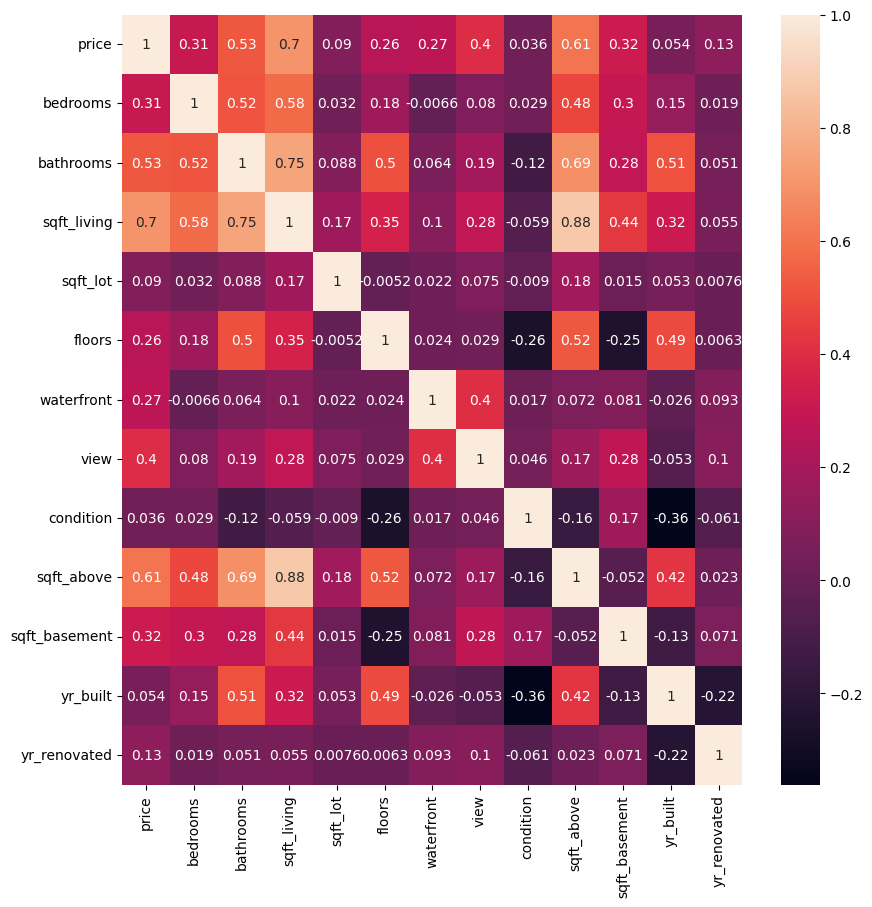

In [17]:
plt.figure(figsize=(10,10))
sns.heatmap(data=dataset.corr(),annot=True)
plt.show()

In [74]:
x = dataset.drop(columns = ["price"])

In [76]:
y = dataset["price"]

In [78]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x),columns=x.columns)

In [80]:
x_train , x_test , y_train , y_test =  train_test_split(x,y,random_state=42,test_size=0.2)

In [82]:
from sklearn.linear_model import LinearRegression , Lasso , Ridge

In [103]:
from sklearn.metrics import mean_absolute_error,mean_squared_error
import numpy as np

# Linear Regression

In [84]:
lr = LinearRegression()
lr.fit(x_train,y_train)
lr.score(x_test,y_test)*100

59.880111297339276

In [108]:
print(mean_squared_error(y_test,lr.predict(x_test)))
print(mean_absolute_error(y_test,lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,lr.predict(x_test))))

60651928701.7925
158277.11204656793
246276.12288200515


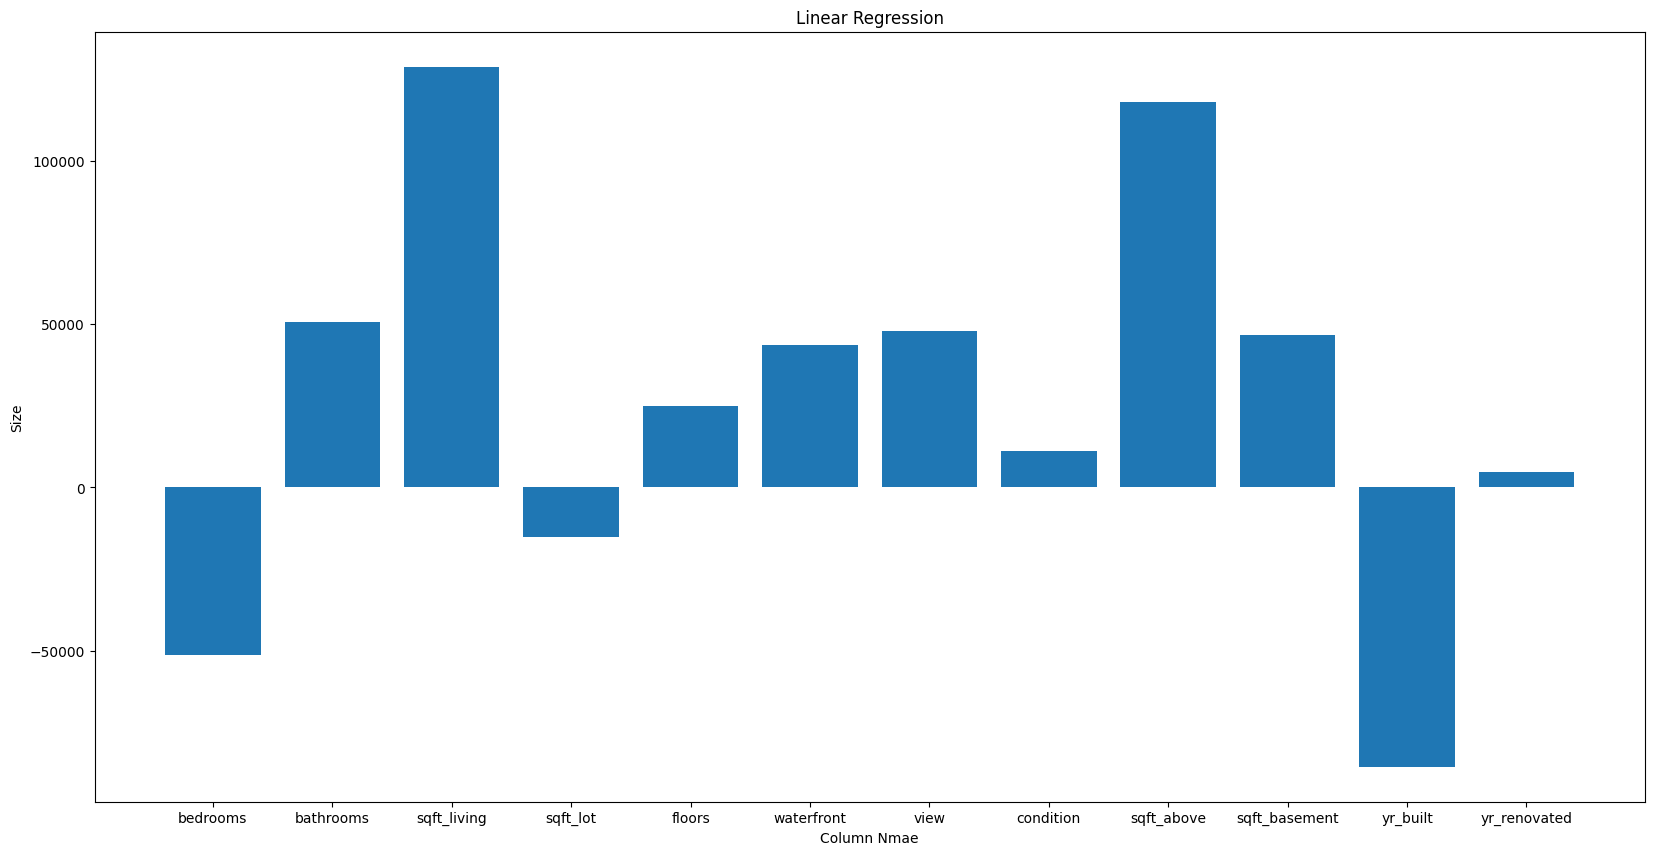

In [92]:
plt.figure(figsize=(20,10))
plt.bar(x.columns,lr.coef_)
plt.title("Linear Regression")
plt.xlabel("Column Nmae")
plt.ylabel("Size")
plt.show()

# Lasso

In [96]:
la = Lasso(alpha=0.01)
la.fit(x_train,y_train)
la.score(x_test,y_test)*100

C:\Users\sujal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.543e+13, tolerance: 2.259e+11
  model = cd_fast.enet_coordinate_descent(


59.880111518217284

In [109]:
print(mean_squared_error(y_test,la.predict(x_test)))
print(mean_absolute_error(y_test,la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,la.predict(x_test))))

60651928367.87642
158277.1126109585
246276.12220407487


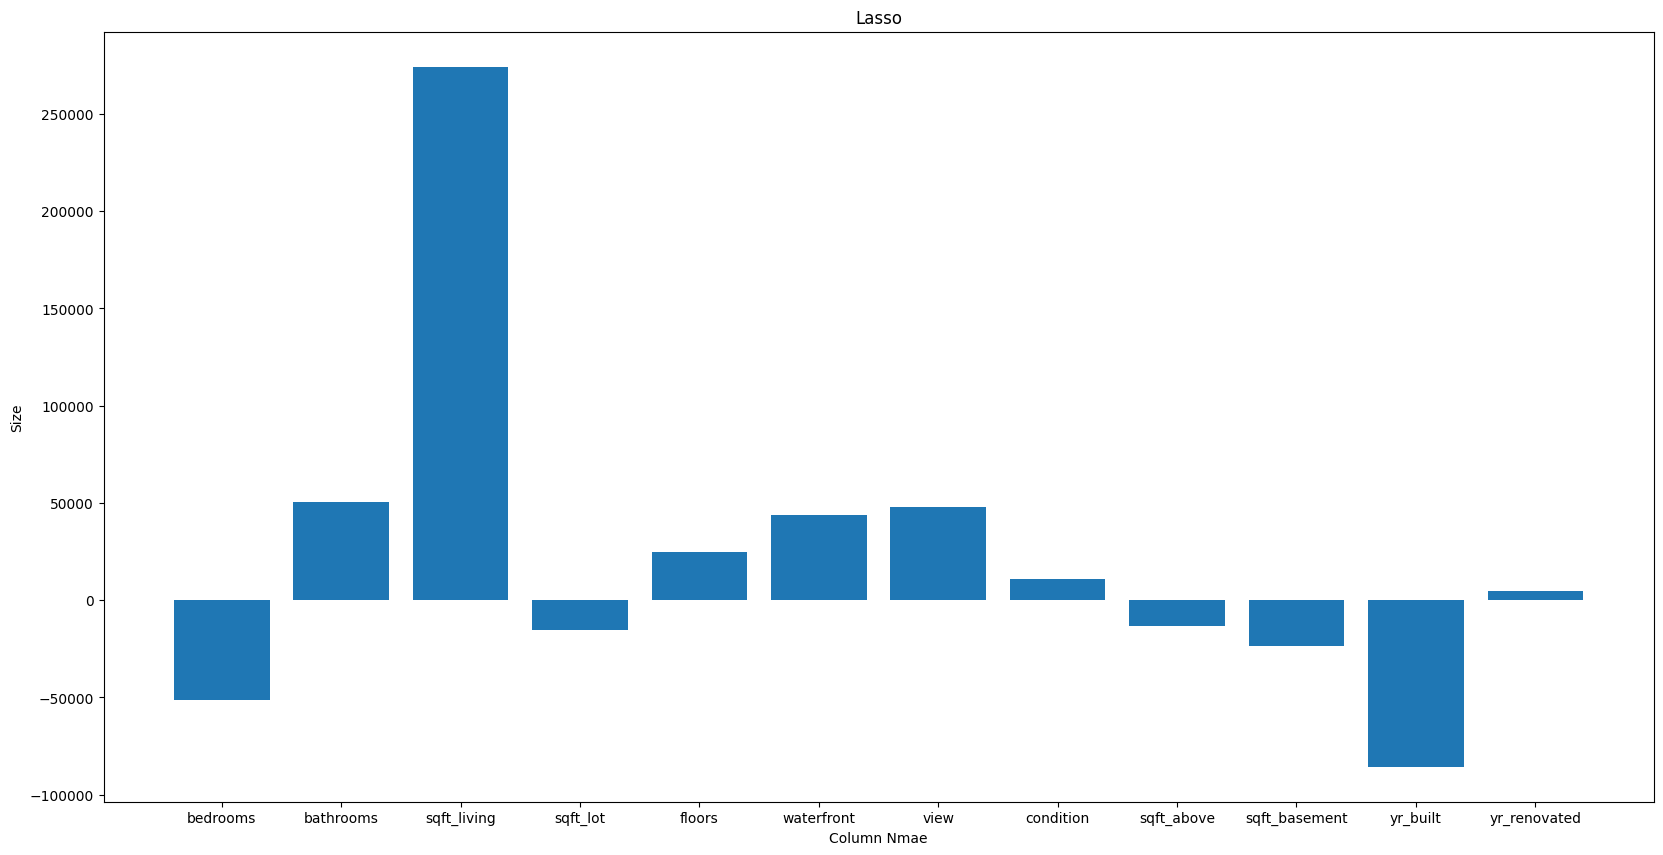

In [97]:
plt.figure(figsize=(20,10))
plt.bar(x.columns,la.coef_)
plt.title("Lasso")
plt.xlabel("Column Nmae")
plt.ylabel("Size")
plt.show()

# Ridge

In [100]:
ri = Ridge(alpha=10)
ri.fit(x_train,y_train)
ri.score(x_test,y_test)

0.5987968836897315

In [110]:
print(mean_squared_error(y_test,ri.predict(x_test)))
print(mean_absolute_error(y_test,ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test,ri.predict(x_test))))

60652568070.991615
158264.4841813291
246277.42095245275


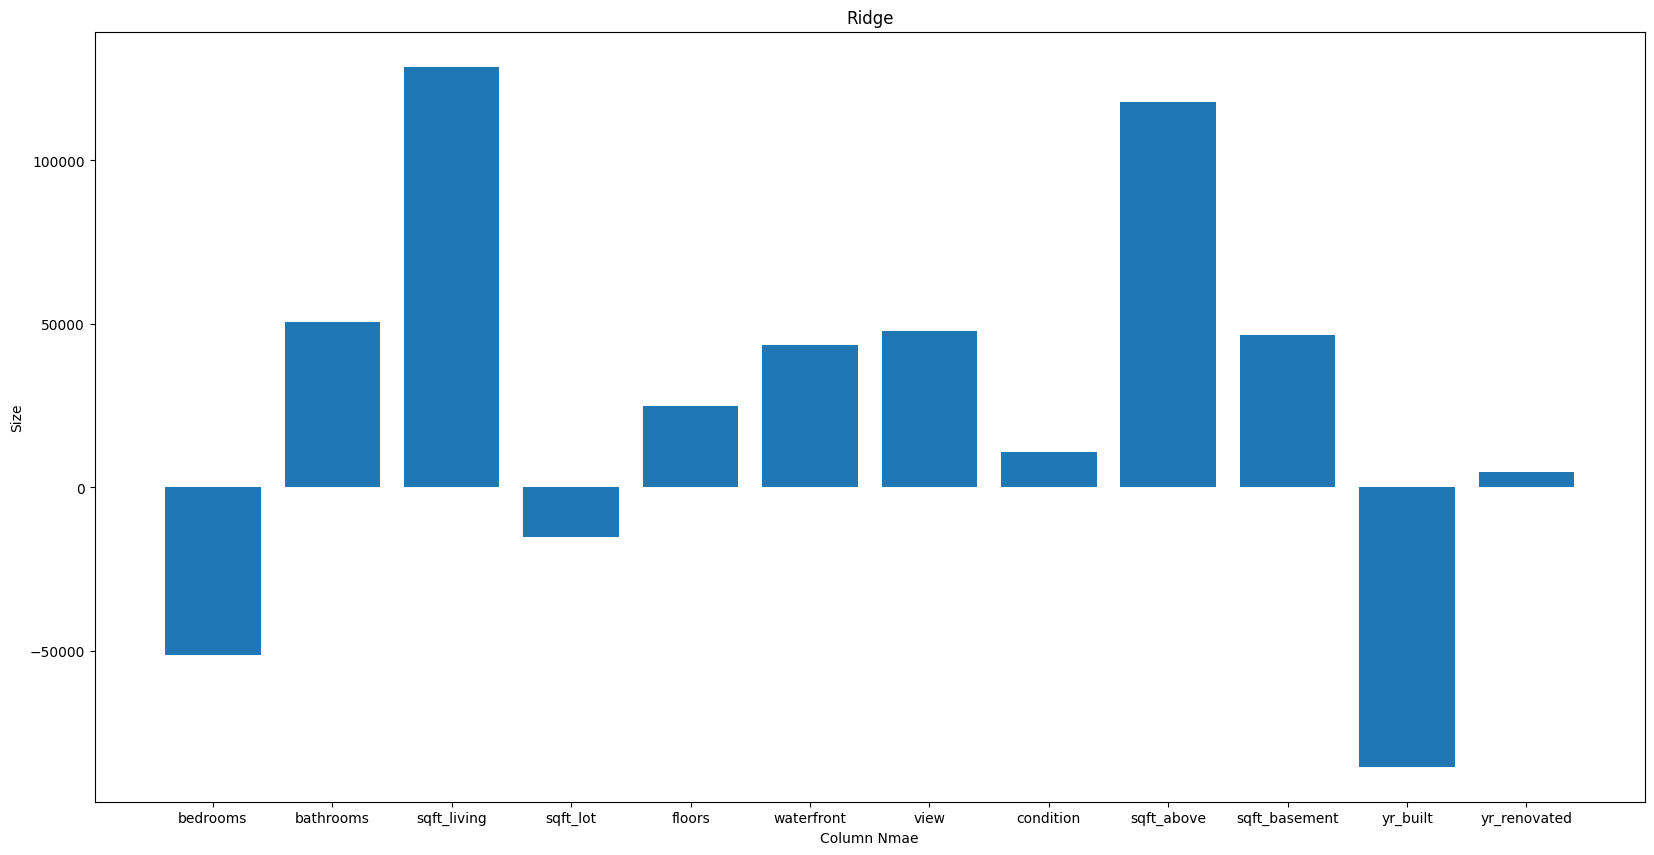

In [102]:
plt.figure(figsize=(20,10))
plt.bar(x.columns,ri.coef_)
plt.title("Ridge")
plt.xlabel("Column Nmae")
plt.ylabel("Size")
plt.show()

In [112]:
df = pd.DataFrame({"col_name":x.columns,"LinearRegression":lr.coef_,"Lasso":la.coef_,"Ridge":ri.coef_})

In [113]:
df

,col_name,LinearRegression,Lasso,Ridge
0,bedrooms,-51404.411927,-51404.399427,-51286.554773
1,bathrooms,50470.913776,50470.848397,50452.310934
2,sqft_living,128798.572078,274232.702790,128709.044402
3,sqft_lot,-15227.011545,-15226.998410,-15192.522536
4,floors,24780.651517,24780.657547,24771.510804
5,waterfront,43709.289357,43709.282859,43693.733569
6,view,47826.435021,47826.431168,47844.942839
7,condition,10953.729780,10953.718929,10968.718782
8,sqft_above,117873.583271,-13253.699670,117785.054456
9,sqft_basement,46735.182226,-23346.065878,46715.036565
